# 1. Import Libraries and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display  # renders DataFrames and plots

plt.rcParams["figure.figsize"] = (10, 5)  # default plot size inches
plt.rcParams["figure.dpi"] = 100   # resolution 100 dots per inch
sns.set_style("whitegrid")  # white background with horizontal grid lines
pd.set_option("display.max_columns", None)  # show all columns in DataFrames (no truncation)
pd.set_option("display.width", None)  # don't wrap columns onto new lines

# 2. Load the NorthStar Dataset
Each CSV represents a separate operational system within NorthStar. The case study mentioned that these systems were originally built for separate businesses acquired

In [2]:
base = "https://raw.githubusercontent.com/samko945/northstar_dataset/refs/heads/main/raw/"

hubs = pd.read_csv(base + "hubs.csv")
customers = pd.read_csv(base + "customers.csv")
drivers = pd.read_csv(base + "drivers.csv")
vehicles = pd.read_csv(base + "vehicles.csv")
orders = pd.read_csv(base + "orders.csv")
deliveries = pd.read_csv(base + "deliveries.csv")
incidents = pd.read_csv(base + "incidents.csv")
complaints = pd.read_csv(base + "complaints.csv")
app_events = pd.read_csv(base + "app_events.csv")

datasets = {
    "hubs": hubs, "customers": customers, "drivers": drivers,
    "vehicles": vehicles, "orders": orders, "deliveries": deliveries,
    "incidents": incidents, "complaints": complaints, "app_events": app_events
}

for name, df in datasets.items():
    print(f"{name:10} -- {df.shape[0]:5} rows, {df.shape[1]:2} cols")

hubs       --     8 rows,  5 cols
customers  --   650 rows,  9 cols
drivers    --   170 rows,  8 cols
vehicles   --   120 rows,  8 cols
orders     --  1250 rows, 11 cols
deliveries --   950 rows, 13 cols
incidents  --   280 rows,  7 cols
complaints --   320 rows, 10 cols
app_events --   640 rows, 10 cols


In [3]:
deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


# 3. Data Quality Check
The case study describes the company has internal systems fragmented, inconsistent, and increasingly difficult to manage. Before any analysis, we must see how fragmented and inconsistent the data actually is

## 3.1

In [4]:
# Shows the structure of the deliveries table
# the number of rows, col names, data types, and missing values
print("Deliveries Info: ")
deliveries.info()

Deliveries Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   delivery_id                    950 non-null    object 
 1   order_id                       950 non-null    object 
 2   driver_id                      950 non-null    object 
 3   vehicle_id                     950 non-null    object 
 4   hub_id                         950 non-null    object 
 5   dispatch_time                  950 non-null    object 
 6   delivery_completed_at          931 non-null    object 
 7   delivery_status                950 non-null    object 
 8   route_distance_km              950 non-null    float64
 9   manual_route_override_count    950 non-null    int64  
 10  proof_of_completion_missing    950 non-null    int64  
 11  customer_rating_post_delivery  936 non-null    float64
 12  fuel_or_charge_cost            9

In [5]:
print("Shape:", deliveries.shape)
print("Columns:", deliveries.columns.tolist())

Shape: (950, 13)
Columns: ['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost']


In [6]:
# summary statistics for numeric columns
# shows count, mean, standard deviation, minimum, maximum, and quartiles
deliveries.describe().round(2)

,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
count,950.00,950.00,950.00,936.00,950.00
mean,13.91,0.97,0.07,3.86,12.84
std,7.48,1.09,0.26,0.89,4.34
min,1.20,0.00,0.00,1.00,2.50
25%,9.14,0.00,0.00,3.36,9.93
50%,12.84,1.00,0.00,4.04,12.64
75%,16.84,2.00,0.00,4.55,15.70
max,41.94,7.00,1.00,5.00,29.43


In [7]:
# Counts how many times each category appears in a column
# view the most common delivery statuses, vehicle types, and customer types

# Count each delivery status
print("Delivery Status: ")
print(deliveries["delivery_status"].value_counts())

# Count each vehicle type
print("\nVehicle Types: ")
print(vehicles["vehicle_type"].value_counts())

# Count each customer type
print("\nCustomer Types: ")
print(customers["customer_type"].value_counts())

Delivery Status: 
delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64

Vehicle Types: 
vehicle_type
EV          43
CargoVan    30
Hybrid      28
Diesel      19
Name: count, dtype: int64

Customer Types: 
customer_type
Consumer      476
SME           124
Enterprise     50
Name: count, dtype: int64


## 3.2 Missing values

In [8]:
# Check dataset for missing values
for name, df in datasets.items():
    # count missing values in each column
    missing = df.isnull().sum()
    # only keep cols with missing values
    missing = missing[missing > 0]
    # if missing values exist, show the column name and count and percentage of missing values
    if len(missing) > 0:
        print(f"\n{name}")
        for col, count in missing.items():
            percent = round(100 * count / len(df), 1)
            print(f"  {col}: {count} missing ({percent}%)")
    else:
        print(f"\n{name} --- No missing values")


hubs --- No missing values

customers
  loyalty_score: 20 missing (3.1%)
  preferred_channel: 13 missing (2.0%)

drivers
  training_score: 7 missing (4.1%)

vehicles
  battery_health_pct: 4 missing (3.3%)

orders
  booking_channel: 25 missing (2.0%)

deliveries
  delivery_completed_at: 19 missing (2.0%)
  customer_rating_post_delivery: 14 missing (1.5%)

incidents
  resolved_hours: 17 missing (6.1%)

complaints
  compensation_amount: 16 missing (5.0%)

app_events
  order_id: 144 missing (22.5%)


The missing values appear to be meaningful than random. For example, battery_health_pct may be missing for vehicles without batteries or vehicles still waiting for diagnostics. customer_rating_post_delivery may be missing where the customer did not leave a rating. resolved_hours may be missing for incidents that are still open, and compensation_amount may be missing where no payout was given.

Because these missing values carry useful operational information, simply deleting the affected rows would remove important signals from the analysis. For example, if a failed delivery has no customer_rating_post_delivery, this may suggest that the customer did not engage after the failure, which could be more serious than a low rating.

## 3.3 Check for duplicates

In [9]:
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        print(f"{name}: {duplicates} duplicate rows")
    else:
        print(f"{name}: No duplicates")

hubs: No duplicates
customers: No duplicates
drivers: No duplicates
vehicles: No duplicates
orders: No duplicates
deliveries: No duplicates
incidents: No duplicates
complaints: No duplicates
app_events: No duplicates


## 3.4 Inconsistent zone names
This inconsistency is visible in the data and is evidence of fragmented systems:

In [10]:
customers["home_zone"].value_counts()

,count
home_zone,
SOUTH,50
RiverSide,49
East,48
WEST,45
CENTRAL,44
West,43
South,42
Riverside,42
EAST,41


In [11]:
# Show the different zone names before cleaning
print("Zones in customers (before):", sorted(customers["home_zone"].dropna().unique()))
print("Zones in orders pickup (before):", sorted(orders["pickup_zone"].dropna().unique()))
print("Zones in drivers (before):", sorted(drivers["base_zone"].dropna().unique()))
print("Zones in app_events (before):", sorted(app_events["zone_context"].dropna().unique()))

Zones in customers (before): ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']
Zones in orders pickup (before): ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']
Zones in drivers (before): ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']
Zones in app_events (before): ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']


# 4 Data Cleaning

## 4.1 Zone standardisation

In [12]:
print("home_zone dtype:", customers["home_zone"].dtype)
print("Unique zone values before cleaning:", customers["home_zone"].nunique())

home_zone dtype: object
Unique zone values before cleaning: 16


In [13]:
def clean_zone(z):
    """Standardise zone names using Week 6 string methods."""
    # check for NaN before string operations
    if pd.isna(z):
        return z
    # Convert the value to text, remove extra spaces, and make it lowercase
    z = str(z).strip().lower()
    z = z.replace("ctr", "central")
    return z

# Apply the cleaning function to each zone column
customers["home_zone"]     = customers["home_zone"].apply(clean_zone)
drivers["base_zone"]       = drivers["base_zone"].apply(clean_zone)
vehicles["assigned_zone"]  = vehicles["assigned_zone"].apply(clean_zone)
orders["pickup_zone"]      = orders["pickup_zone"].apply(clean_zone)
orders["dropoff_zone"]     = orders["dropoff_zone"].apply(clean_zone)
app_events["zone_context"] = app_events["zone_context"].apply(clean_zone)
hubs["zone"]               = hubs["zone"].apply(clean_zone)

print("Zones after cleaning:", sorted(customers["home_zone"].dropna().unique()))

Zones after cleaning: ['airport', 'central', 'east', 'north', 'riverside', 'south', 'west']


The zone columns were cleaned so that the same location is written in a consistent format across all data. The function removes extra spaces, converts text to lowercase, and replaces the abbreviation ctr with central. This helps avoid duplicate categories caused by small formatting differences, such as Central, central, and ctr being treated as separate zones.

## 4.2 DateTime parsing

In [14]:
print("dispatch_time dtype BEFORE:", deliveries["dispatch_time"].dtype)

orders["order_created_at"] = pd.to_datetime(orders["order_created_at"])
deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"])
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"])
complaints["created_at"] = pd.to_datetime(complaints["created_at"])
incidents["reported_at"] = pd.to_datetime(incidents["reported_at"])
app_events["event_timestamp"] = pd.to_datetime(app_events["event_timestamp"])
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
vehicles["commission_date"] = pd.to_datetime(vehicles["commission_date"])

print("dispatch_time dtype AFTER:", deliveries["dispatch_time"].dtype)
print("Date range:", deliveries["dispatch_time"].min(), "to", deliveries["dispatch_time"].max())

dispatch_time dtype BEFORE: object
dispatch_time dtype AFTER: datetime64[ns]
Date range: 2024-01-01 03:20:00 to 2025-12-31 17:27:00


## 4.3 Numeric Conversion

In [15]:
print("battery_health_pct dtype before:", vehicles["battery_health_pct"].dtype)
vehicles["battery_health_pct"].head()

battery_health_pct dtype before: float64


,battery_health_pct
0,71.8
1,67.9
2,91.7
3,NaN
4,58.6


In [16]:
# Convert battery health from text to whole numbers.
#  invalid values become missing values
vehicles["battery_health_pct"] = pd.to_numeric(vehicles["battery_health_pct"], errors="coerce")
complaints["compensation_amount"] = pd.to_numeric(complaints["compensation_amount"], errors="coerce")

print("battery_health_pct dtype:", vehicles["battery_health_pct"].dtype)
print("compensation_amount dtype:", complaints["compensation_amount"].dtype)

battery_health_pct dtype: float64
compensation_amount dtype: float64


## 4.4 Boolean Conversion

In [17]:
# before conversion the column is stored as whole numbers
#  0 = no, delivery has proof, proof is NOT missing
#  1 = yes, delivery has no proof, proof IS missing
print("proof_of_completion_missing dtype before:", deliveries["proof_of_completion_missing"].dtype)

# counts how many rows have each value
print(deliveries["proof_of_completion_missing"].value_counts())

proof_of_completion_missing dtype before: int64
proof_of_completion_missing
0    881
1     69
Name: count, dtype: int64


In [18]:
# converts the column from int64 (0/1) to bool (False/True)
deliveries["proof_of_completion_missing"] = deliveries["proof_of_completion_missing"].astype(bool)

# After conversion dtype is now bool
# the counts are the same only the labels have changed to give the data meaning and readability in English
print("proof_of_completion_missing dtype:", deliveries["proof_of_completion_missing"].dtype)
print(deliveries["proof_of_completion_missing"].value_counts())

proof_of_completion_missing dtype: bool
proof_of_completion_missing
False    881
True      69
Name: count, dtype: int64


## 4.5 Handle missing values

In [19]:
print("Missing customer_rating_post_delivery:", deliveries["customer_rating_post_delivery"].isnull().sum())
print("Missing compensation_amount:", complaints["compensation_amount"].isnull().sum())
print("Missing preferred_channel:", customers["preferred_channel"].isnull().sum())

Missing customer_rating_post_delivery: 14
Missing compensation_amount: 16
Missing preferred_channel: 13


In [20]:
# Keep missing rating as may mean the customer did not leave feedback
print("Ratings left as NaN:", deliveries["customer_rating_post_delivery"].isna().sum())

# Replace missing compensation amounts with 0
print("compensation_amount NaN BEFORE:", complaints["compensation_amount"].isna().sum())
complaints["compensation_amount"] = complaints["compensation_amount"].fillna(0)
print("compensation_amount NaN AFTER:", complaints["compensation_amount"].isna().sum())

# Replace missing preferred channels with "Unknown"
print("preferred_channel NaN BEFORE:", customers["preferred_channel"].isna().sum())
customers["preferred_channel"] = customers["preferred_channel"].fillna("Unknown")
print("preferred_channel NaN AFTER:", customers["preferred_channel"].isna().sum())

Ratings left as NaN: 14
compensation_amount NaN BEFORE: 16
compensation_amount NaN AFTER: 0
preferred_channel NaN BEFORE: 13
preferred_channel NaN AFTER: 0


## 4.6 Derived columns

In [21]:
deliveries["delivery_status"].value_counts()

,count
delivery_status,
OnTime,616
Delayed,202
Failed,132


In [ ]:
# is_failed is a new binary column derived from delivery_status
# 1 = the delivery was marked failed, 0 = any other status
# Storing it as 0/1 rather than text to use directly in numeric operations such as SUM() in SQL or mean() in R
deliveries["is_failed"] = (deliveries["delivery_status"] == "Failed").astype(int)
print("is_failed:", deliveries["is_failed"].value_counts().to_dict())

# dispatch_month extracts the month from dispatch_time so deliveries can be grouped and compared by month
deliveries["dispatch_month"] = deliveries["dispatch_time"].astype(str).str[:7]
print("dispatch_month sample:", deliveries["dispatch_month"].value_counts().head(3).to_dict())

In [22]:
def battery_risk(percent):
    # called once per vehicle row with the battery_health_pct value
    if pd.isna(percent): return "Unknown"
    elif percent < 50: return "Critical"
    elif percent < 70: return "Warning"
    else: return "Healthy"

# apply the function to every row, creating a new column
vehicles["battery_risk"] = vehicles["battery_health_pct"].apply(battery_risk)
print("battery_risk:", vehicles["battery_risk"].value_counts().to_dict())

battery_risk: {'Healthy': 81, 'Warning': 32, 'Unknown': 4, 'Critical': 3}


# 5. Download Cleaned CSVs

In [24]:
import os
import shutil
from google.colab import files

output_dir = "cleaned"
os.makedirs(output_dir, exist_ok=True)

datasets = {
    "hubs": hubs,
    "customers": customers,
    "drivers": drivers,
    "vehicles": vehicles,
    "orders": orders,
    "deliveries": deliveries,
    "incidents": incidents,
    "complaints": complaints,
    "app_events": app_events
}

for name, df in datasets.items():
    filename = f"{name}_cleaned.csv"
    path = os.path.join(output_dir, filename)
    df.to_csv(path, index=False)
    print(f"Saved: {path} ({len(df)} rows)")

# Create ZIP file
shutil.make_archive("cleaned_csv_files", "zip", output_dir)

# Download ZIP file
files.download("cleaned_csv_files.zip")

Saved: cleaned/hubs_cleaned.csv (8 rows)
Saved: cleaned/customers_cleaned.csv (650 rows)
Saved: cleaned/drivers_cleaned.csv (170 rows)
Saved: cleaned/vehicles_cleaned.csv (120 rows)
Saved: cleaned/orders_cleaned.csv (1250 rows)
Saved: cleaned/deliveries_cleaned.csv (950 rows)
Saved: cleaned/incidents_cleaned.csv (280 rows)
Saved: cleaned/complaints_cleaned.csv (320 rows)
Saved: cleaned/app_events_cleaned.csv (640 rows)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import os
import shutil
from google.colab import files

output_dir = "cleaned"
os.makedirs(output_dir, exist_ok=True)

for name, df in datasets.items():
    json_path = os.path.join(output_dir, f"{name}_cleaned.json")

    df.to_json(
        json_path,
        orient="records",
        indent=4
    )

    print(f"Saved: {json_path} ({len(df)} rows)")

# Create ZIP file from the cleaned folder
shutil.make_archive("cleaned_json_files", "zip", output_dir)

# Download ZIP file
files.download("cleaned_json_files.zip")

Saved: cleaned/hubs_cleaned.json (8 rows)
Saved: cleaned/customers_cleaned.json (650 rows)
Saved: cleaned/drivers_cleaned.json (170 rows)
Saved: cleaned/vehicles_cleaned.json (120 rows)
Saved: cleaned/orders_cleaned.json (1250 rows)
Saved: cleaned/deliveries_cleaned.json (950 rows)
Saved: cleaned/incidents_cleaned.json (280 rows)
Saved: cleaned/complaints_cleaned.json (320 rows)
Saved: cleaned/app_events_cleaned.json (640 rows)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 6. Statistics
Explore characteristics of NorthStar operations

## 6.1 Deliveries overview

In [26]:
deliveries.describe().round(2)

,dispatch_time,delivery_completed_at,route_distance_km,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost
count,950,931,950.00,950.00,936.00,950.00
mean,2024-12-20 13:10:27.536841984,2024-12-19 20:19:52.772387584,13.91,0.97,3.86,12.84
min,2024-01-01 03:20:00,2024-01-01 15:35:48.325916,1.20,0.00,1.00,2.50
25%,2024-06-21 17:54:00,2024-06-18 14:13:03.296665088,9.14,0.00,3.36,9.93
50%,2024-12-12 14:19:30,2024-12-13 02:04:50.318852096,12.84,1.00,4.04,12.64
75%,2025-06-12 01:39:15,2025-06-12 00:14:26.336295936,16.84,2.00,4.55,15.70
max,2025-12-31 17:27:00,2025-12-31 18:05:52.415764,41.94,7.00,5.00,29.43
std,NaN,NaN,7.48,1.09,0.89,4.34


In [27]:
print("Delivery Status Distribution:")
status_counts = deliveries["delivery_status"].value_counts()
status_pct = deliveries["delivery_status"].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({"Count": status_counts, "Percentage": status_pct}))

print("\nDelivery Numeric Summary: ")
deliveries[["route_distance_km", "manual_route_override_count",
"customer_rating_post_delivery", "fuel_or_charge_cost"]].describe().round(2)

Delivery Status Distribution:
                 Count  Percentage
delivery_status                   
OnTime             616        64.8
Delayed            202        21.3
Failed             132        13.9

Delivery Numeric Summary: 


,route_distance_km,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost
count,950.00,950.00,936.00,950.00
mean,13.91,0.97,3.86,12.84
std,7.48,1.09,0.89,4.34
min,1.20,0.00,1.00,2.50
25%,9.14,0.00,3.36,9.93
50%,12.84,1.00,4.04,12.64
75%,16.84,2.00,4.55,15.70
max,41.94,7.00,5.00,29.43


## 6.2 Numpy statistics

In [28]:
col = deliveries["route_distance_km"]
arr = col.values
print("Type:", type(arr))
print("First 5 values:", arr[:5])

Type: <class 'numpy.ndarray'>
First 5 values: [17.26 10.34  7.92 16.42 14.52]


In [29]:
arr = col.values  # convert to numpy array

print("NumPy Statistics: route_distance_km")
print(f"Mean: {np.mean(arr):.2f}")  # average route distance
print(f"Median: {np.median(arr):.2f}")  # middle value, less affected by very long outlier routes
print(f"Std dev: {np.std(arr):.2f}")  # spread, high value means routes vary widely in length
print(f"Min: {np.min(arr):.2f}")  # shortest route
print(f"Max: {np.max(arr):.2f}")  # longest route
q = np.quantile(arr, [0.25, 0.5, 0.75])
print(
    f"Q1/Q2/Q3: {q[0]:.2f} / {q[1]:.2f} / {q[2]:.2f}"
)  # so 50% of the values are between 9.14 and 16.84

NumPy Statistics: route_distance_km
Mean: 13.91
Median: 12.84
Std dev: 7.47
Min: 1.20
Max: 41.94
Q1/Q2/Q3: 9.14 / 12.84 / 16.84


NumPy was used to calculate summary statistics for route_distance_km. The average route distance is about 13.91 km, while the median is 12.84 km. This suggests that most deliveries are around this distance, but some longer routes increase the average slightly. The minimum distance is 1.20 km and the maximum is 41.94 km, showing that the dataset includes both short and much longer delivery routes.

## 6.3 Orders, Customers, and Vehicles

In [32]:
orders.head()
# customers.head()
# vehicles.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,airport,south,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,north,airport,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,west,airport,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,riverside,north,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,riverside,south,Low,125.58,Phone,0


In [34]:
print("Service Type Distribution:")
print(orders["service_type"].value_counts())

print("\nOrder Value Summary:")
print(orders["order_value"].describe().round(2))

print("\nAccount Status:")
print(customers["account_status"].value_counts())

print("\nMaintenance Status:")
print(vehicles["maintenance_status"].value_counts())

print("\nBattery Health Summary:")
print(vehicles["battery_health_pct"].describe().round(2))

Service Type Distribution:
service_type
Passenger    341
Parcel       308
Retail       297
Business     165
Medical      139
Name: count, dtype: int64

Order Value Summary:
count    1250.00
mean       91.05
std        60.92
min         2.04
25%        47.92
50%        76.53
75%       121.10
max       510.06
Name: order_value, dtype: float64

Account Status:
account_status
Active       552
Dormant       78
Suspended     20
Name: count, dtype: int64

Maintenance Status:
maintenance_status
Active       67
InRepair     36
Scheduled    17
Name: count, dtype: int64

Battery Health Summary:
count    116.00
mean      76.79
std       12.70
min       42.00
25%       68.20
50%       78.05
75%       85.78
max      100.00
Name: battery_health_pct, dtype: float64


This overview shows the main patterns across orders, customers, and vehicles. Passenger, parcel, and retail are the most common service types, meaning they make up most of the platform activity. The average order value is £91.05, but the median is lower at £76.53, which suggests that some high-value orders increase the average. Most customers are active, while only a smaller number are dormant or suspended. The vehicle summary helps show the condition of the fleet, including maintenance status and battery health, which are important for understanding operational reliability.

# 7. Combined analysis

## 7.1 Create one merged delivery table
This combines the delivery data with order, driver, vehicle, and hub information.
Here each delivery can be analysed with all related details in one place.

In [ ]:
print("deliveries shape:", deliveries.shape)
print("orders shape:", orders.shape)
print("drivers shape:", drivers.shape)
print("vehicles shape:", vehicles.shape)
print("hubs shape:", hubs.shape)

In [35]:
master = (
    deliveries
    .merge(orders, on="order_id", how="left")
    .merge(drivers, on="driver_id", how="left")
    .merge(vehicles, on="vehicle_id", how="left")
    .merge(hubs, on="hub_id", how="left")
)

print(f"Master table: {master.shape[0]} rows, {master.shape[1]} columns")
master.head(3)

Master table: 950 rows, 42 columns


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,battery_risk,hub_name,zone,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,False,3.07,12.05,C0567,Business,2024-06-18 09:48:00,6,central,central,Medium,151.14,Web,0,airport,PartTime,13,88.9,4.75,Morning,1,EV,central,2024-06-09 16:18:00,78.4,29849,Active,v2.2,Healthy,Central Core,central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,False,5.00,13.41,C0520,Parcel,2025-01-11 17:15:00,2,riverside,north,Medium,10.04,App,1,central,PartTime,11,69.2,4.61,Evening,1,Diesel,airport,2025-09-17 08:52:00,68.6,78468,Active,v2.2,Warning,South Link,south,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,False,4.98,8.51,C0480,Medical,2025-06-02 19:12:00,2,central,north,Medium,141.93,Web,0,central,FullTime,8,78.8,4.38,Flexible,1,Diesel,east,2025-12-09 16:47:00,55.9,15278,Active,v2.2,Warning,South Link,south,Dispatch,78


The merged table brings the separate data together into one table. Each delivery is now linked to its order details, driver, vehicle, and hub. This makes it easier to analyse operational problems because the information is no longer spread across separate tables. It also supports the case study issue, where complaints, failed deliveries, missed journeys, and driver incidents need to be connected in one place.

## 7.2 Profitability by Service Type

In [36]:
master["service_type"].value_counts()

,count
service_type,
Passenger,262
Parcel,230
Retail,224
Business,126
Medical,108


In [37]:
# Shows how each service type performas
g = master.groupby("service_type")
service_perf = pd.DataFrame({
    "total": g["delivery_id"].count(),
    "avg_value": g["order_value"].mean().round(2),
    "avg_fuel": g["fuel_or_charge_cost"].mean().round(2),
    "avg_rating": g["customer_rating_post_delivery"].mean().round(2),
})

# Count failed deliveries per service type using a filter
failed_counts = master[master["delivery_status"] == "Failed"].groupby("service_type")["delivery_id"].count()
service_perf["failed"] = failed_counts.reindex(service_perf.index).fillna(0).astype(int)
service_perf["fail_rate_pct"] = (100 * service_perf["failed"] / service_perf["total"]).round(1)

# average compensation from complaints
comp_linked = complaints.merge(orders[["order_id", "service_type"]], on="order_id", how="left")
avg_comp = comp_linked.groupby("service_type")["compensation_amount"].mean().round(2).rename("avg_compensation")
service_perf["avg_compensation"] = avg_comp.reindex(service_perf.index).fillna(0)

# profitability = order_value - fuel_cost - compensation
service_perf["avg_net_margin"] = (
    service_perf["avg_value"] - service_perf["avg_fuel"] - service_perf["avg_compensation"]
).round(2)

service_perf.sort_values("avg_net_margin")

,total,avg_value,avg_fuel,avg_rating,failed,fail_rate_pct,avg_compensation,avg_net_margin
service_type,,,,,,,,
Medical,108,86.53,12.77,3.84,16,14.8,20.00,53.76
Retail,224,86.81,12.97,3.87,28,12.5,17.91,55.93
Parcel,230,90.15,13.08,3.90,25,10.9,19.01,58.06
Business,126,97.45,13.14,3.85,25,19.8,20.79,63.52
Passenger,262,97.19,12.40,3.85,38,14.5,19.73,65.06


Business deliveries have the highest failure rate at 19.8%, which suggests they may be operationally risky despite having a high average order value. Passenger deliveries are also important because they have the highest number of deliveries and a high average order value, but their failure rate is still noticeable at 14.5%. Parcel deliveries appear more stable, with the lowest failure rate and the highest average rating. Overall, this table helps identify which service types may be more profitable and which ones may need operational improvement.

## 7.3 Repeat Failure Customers

In [38]:
print("Failed deliveries:", (master["delivery_status"] == "Failed").sum())
master[master["delivery_status"] == "Failed"]["customer_id"].value_counts().head(10)

Failed deliveries: 132


,count
customer_id,
C0186,2
C0492,2
C0530,2
C0021,2
C0533,2
C0197,1
C0567,1
C0504,1
C0619,1


In [39]:
# Keep only failed deliveries
failed_deliveries = master[master["delivery_status"] == "Failed"]

# Count failed deliveries for each customer and calculate lost order value
repeat_failures = (
    failed_deliveries.groupby("customer_id")
    .agg(failed_count=("delivery_id", "count"), total_lost_value=("order_value", "sum"))
    .reset_index()
)

# add details such as type, zone, loyalty score, and account status
repeat_failures = repeat_failures.merge(
    customers[
        ["customer_id", "customer_type", "home_zone", "loyalty_score", "account_status"]
    ],
    on="customer_id",
    how="left",
)

# keep only customers with 2 or more failed deliveries
repeat_failures = repeat_failures[repeat_failures["failed_count"] >= 2]
repeat_failures = repeat_failures.sort_values("failed_count", ascending=False)

print(f"Customers with 2 or more failed deliveries: {len(repeat_failures)}")
repeat_failures

Customers with 2 or more failed deliveries: 5


,customer_id,failed_count,total_lost_value,customer_type,home_zone,loyalty_score,account_status
1,C0021,2,150.82,SME,central,63.6,Active
30,C0186,2,101.75,Consumer,east,57.5,Dormant
96,C0492,2,160.70,Consumer,west,60.0,Active
103,C0530,2,236.08,SME,west,55.9,Active
104,C0533,2,144.75,Consumer,south,46.9,Active


There are 5 customers with two or more failed deliveries. These customers are important because repeated delivery failures may increase the risk of complaints, lost trust, or customer churn. The total_lost_value column shows the value of the failed orders linked to each customer. This helps identify which repeat failure customers may need the most attention.

## 7.4 Driver Performance check
This section checks driver performance by comparing total deliveries, failed deliveries, customer ratings, route overrides, fuel/charging cost, and training score.
The aim is to identify drivers who may need extra support or training.

In [40]:
arr_scores = drivers["training_score"].dropna().values
print(f"Training score -- mean: {np.mean(arr_scores):.1f}, min: {np.min(arr_scores):.1f}, max: {np.max(arr_scores):.1f}")

Training score -- mean: 74.9, min: 40.6, max: 99.0


In [43]:
# Build one row per driver with main performance measures
g = master.groupby("driver_id")
driver_dash = pd.DataFrame({
    "total_deliveries": g["delivery_id"].count(),
    "avg_overrides": g["manual_route_override_count"].mean().round(2),
    "avg_rating": g["customer_rating_post_delivery"].mean().round(2),
    "total_fuel_cost": g["fuel_or_charge_cost"].sum().round(2),
}).reset_index()

# Count failures per driver using a filter
failed_per_driver = (
    master[master["delivery_status"] == "Failed"]
    .groupby("driver_id")["delivery_id"].count()
    .rename("failed")
    .reset_index()
)
driver_dash = driver_dash.merge(failed_per_driver, on="driver_id", how="left")
driver_dash["failed"] = driver_dash["failed"].fillna(0)

# add training score
driver_dash = driver_dash.merge(
    drivers[["driver_id", "training_score"]], on="driver_id", how="left"
)

driver_dash["fail_rate_pct"] = (
    100 * driver_dash["failed"] / driver_dash["total_deliveries"]
).round(1)

driver_dash = driver_dash.round(2)
print(f"driver_dash: {len(driver_dash)} drivers")

driver_dash: 170 drivers


In [44]:
# Use a minimum of 5 deliveries - avoid unfairly ranking new drivers
print("Top 15 drivers by failure rate (min 5 deliveries):")
driver_dash[driver_dash["total_deliveries"] >= 5].sort_values(
    "fail_rate_pct", ascending=False
).head(15)

Top 15 drivers by failure rate (min 5 deliveries):


,driver_id,total_deliveries,avg_overrides,avg_rating,total_fuel_cost,failed,training_score,fail_rate_pct
91,D092,5,0.40,3.38,54.41,3.0,88.2,60.0
103,D104,7,1.71,3.93,95.38,4.0,87.7,57.1
23,D024,8,1.12,3.44,102.49,4.0,71.4,50.0
9,D010,7,0.86,4.15,75.07,3.0,70.0,42.9
4,D005,5,1.20,3.53,56.56,2.0,69.7,40.0
143,D144,5,1.20,3.75,62.34,2.0,85.0,40.0
94,D095,5,1.00,3.26,69.35,2.0,99.0,40.0
142,D143,5,1.80,3.76,62.74,2.0,68.5,40.0
22,D023,6,0.33,3.90,87.23,2.0,79.1,33.3
81,D082,6,0.67,4.02,93.88,2.0,74.1,33.3


The table highlights drivers with the highest failure rates after filtering out very small delivery counts. This makes the comparison fairer. Drivers with high failure rates should be reviewed alongside their route overrides, customer ratings, and training scores to see whether the issue may be linked to routing decisions, service quality, or training needs.

## 7.5 Incident impact

In [45]:
incidents["incident_type"].value_counts()

,count
incident_type,
ProofMissing,46
CustomerNoShow,44
RouteDeviation,43
VehicleFault,37
BatteryAlert,36
AppSyncError,31
TemperatureIssue,29
SafetyNearMiss,14


In [46]:
# Join each incident to the delivery it belongs to
incident_impact = incidents.merge(
    deliveries[["delivery_id", "delivery_status", "driver_id", "vehicle_id", "hub_id"]],
    on="delivery_id",
    how="left",
)

# summarise incidents by type to see which problems are most serious
g = incident_impact.groupby("incident_type")
incident_summary = pd.DataFrame({
    "total": g["incident_id"].count(),
    "avg_resolved_hours": g["resolved_hours"].mean().round(1),
})

# count linked failures
failed_incidents = incident_impact[incident_impact["delivery_status"] == "Failed"]
linked = failed_incidents.groupby("incident_type")["incident_id"].count().rename("linked_failures")
incident_summary["linked_failures"] = linked.reindex(incident_summary.index).fillna(0)

# count unresolved incidents
unresolved_incidents = incident_impact[incident_impact["resolution_status"].isin(["Open", "Escalated"])]
unresolved = unresolved_incidents.groupby("incident_type")["incident_id"].count().rename("unresolved")
incident_summary["unresolved"] = unresolved.reindex(incident_summary.index).fillna(0)

# convert linked failures into a percentage for easier comparison
incident_summary["failure_link_pct"] = (
    100 * incident_summary["linked_failures"] / incident_summary["total"]
).round(1)

# Ssow the incident types most linked to failed deliveries
incident_summary.sort_values("failure_link_pct", ascending=False)

,total,avg_resolved_hours,linked_failures,unresolved,failure_link_pct
incident_type,,,,,
TemperatureIssue,29,12.9,6,9,20.7
AppSyncError,31,12.7,5,10,16.1
SafetyNearMiss,14,9.7,2,8,14.3
BatteryAlert,36,11.7,5,16,13.9
ProofMissing,46,10.8,6,17,13.0
RouteDeviation,43,13.7,4,20,9.3
VehicleFault,37,9.1,3,16,8.1
CustomerNoShow,44,13.9,3,16,6.8


This table shows which incident types are most connected to failed deliveries. TemperatureIssue has the highest failure link percentage at 20.7%, meaning it is the incident type most strongly linked with delivery failure. AppSyncError is also important because it has a high failure link rate of 16.1% and 10 unresolved cases. BatteryAlert, ProofMissing, and RouteDeviation have many unresolved cases, so they may need operational attention even if their failure link percentage is lower. Overall, the biggest risks are incident types that have both a high failure link percentage and many unresolved cases.

# 8. Visualisatons

### Chart 1: Delivery Status Distribution
Display the overall scale of the delivery reliability problem

In [47]:
deliveries["delivery_status"].value_counts()

,count
delivery_status,
OnTime,616
Delayed,202
Failed,132


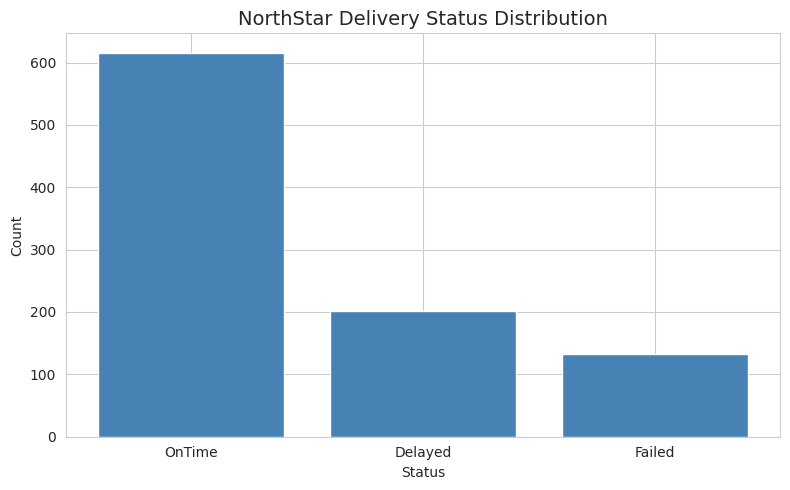

In [48]:
status_counts = deliveries["delivery_status"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(status_counts.index, status_counts.values, color="steelblue")
plt.title("NorthStar Delivery Status Distribution", fontsize=14)
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The chart shows that most deliveries are completed on time, which suggests the service is generally good. However, there are still a number of delayed and failed deliveries. These two categories represent service problems because the customer did not receive the expected delivery experience.

The number of delayed deliveries is higher than the failed deliveries, meaning delays are a more common issue. Failed deliveries are fewer, but they are more serious because the delivery was not completed at all.

### Chart 2: Delivery Status Breakdown by Hub

Case study link: The operations director believes the problem is concentrated in specific underperforming hubs.

In [49]:
master["hub_name"].value_counts()

,count
hub_name,
North Exchange,136
Midtown Relay,128
West Gate,127
East Dock,119
Riverside Hub,115
Central Core,115
South Link,106
Airport Hub,104


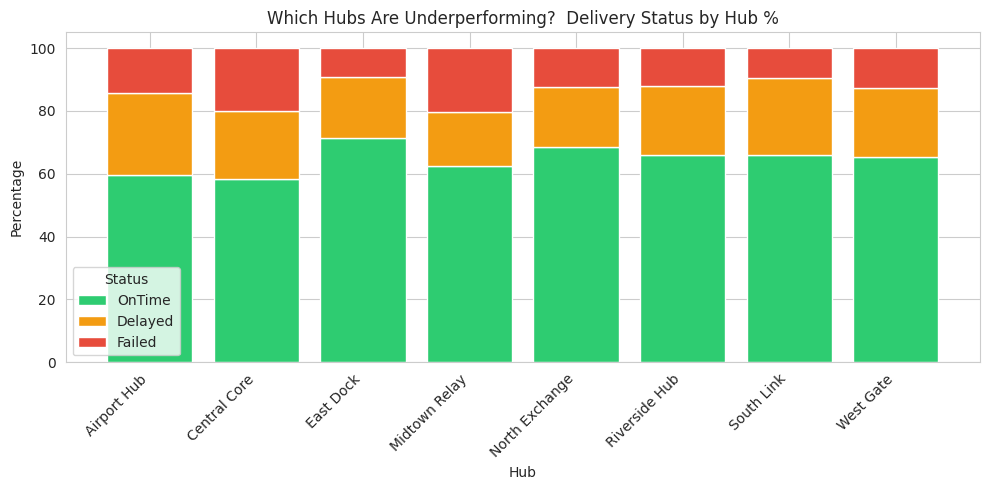

In [50]:
hub_names = sorted(master["hub_name"].dropna().unique())
ontime_pct, delayed_pct, failed_pct = [], [], []

for hub in hub_names:
    hub_rows = master[master["hub_name"] == hub]
    total = len(hub_rows)
    ontime_pct.append(100 * (hub_rows["delivery_status"] == "OnTime").sum() / total)
    delayed_pct.append(100 * (hub_rows["delivery_status"] == "Delayed").sum() / total)
    failed_pct.append(100 * (hub_rows["delivery_status"] == "Failed").sum() / total)

ontime_arr  = np.array(ontime_pct)
delayed_arr = np.array(delayed_pct)
failed_arr  = np.array(failed_pct)

x = np.arange(len(hub_names))

plt.figure(figsize=(10, 5))
plt.bar(x, ontime_arr,  color="#2ecc71", label="OnTime")
plt.bar(x, delayed_arr, bottom=ontime_arr, color="#f39c12", label="Delayed")
plt.bar(x, failed_arr,  bottom=ontime_arr + delayed_arr, color="#e74c3c", label="Failed")
plt.title("Which Hubs Are Underperforming?  Delivery Status by Hub %")
plt.xlabel("Hub")
plt.ylabel("Percentage")
plt.xticks(x, hub_names, rotation=45, ha="right")
plt.legend(title="Status")
plt.tight_layout()
plt.show()


This chart compares delivery performance across hubs as percentages, so each hub can be compared fairly even if they handle different numbers of deliveries.

Most hubs have a majority of on-time deliveries, but some hubs show larger delayed and failed sections. Central Core and Midtown Relay have weaker performance because their on-time percentages are lower and their failed sections are larger. East Dock appears to perform better, with the highest on-time percentage and a smaller failed section.

This supports the concern that delivery problems may be concentrated in certain hubs rather than spread evenly. The hubs with larger delayed and failed percentages should be reviewed first.

### Chart 3: Order Value Distribution by Service Type

In [51]:
arr_val = master["order_value"].dropna().values
print(f"order_value -- mean: {np.mean(arr_val):.2f}, median: {np.median(arr_val):.2f}, std: {np.std(arr_val):.2f}")

order_value -- mean: 91.86, median: 77.17, std: 61.96


/tmp/ipykernel_1747/33155933.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=service_types)


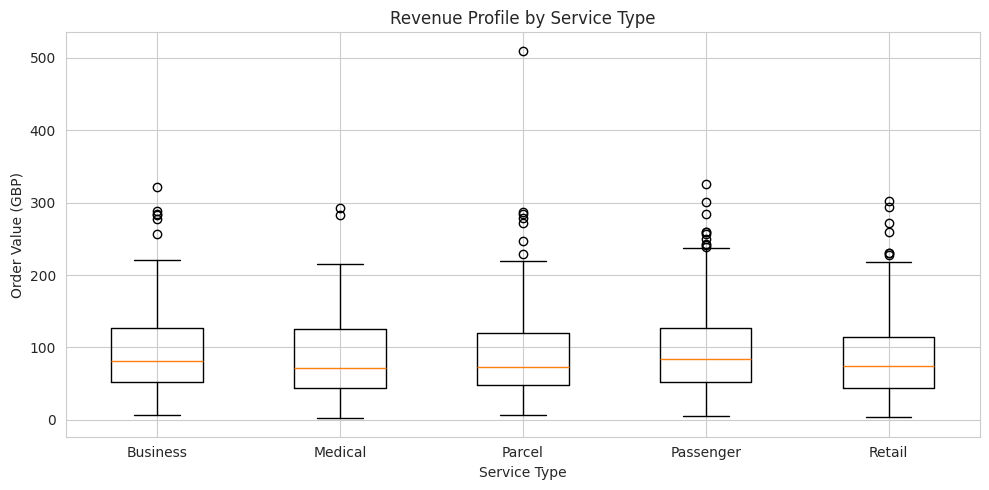

In [52]:
service_types = sorted(master["service_type"].dropna().unique())
box_data = [master[master["service_type"] == s]["order_value"].dropna().values for s in service_types]

plt.figure(figsize=(10, 5))
plt.boxplot(box_data, labels=service_types)
plt.title("Revenue Profile by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Order Value (GBP)")
plt.tight_layout()
plt.show()

This box plot shows how order values differ between service types. Most service types have a similar middle range, but there are also high value orders shown as points above the boxes.

Passenger and Business appear to have higher typical order values, while Medical, Parcel, and Retail are more spread out. The wide spread means that order values are not always consistent.

This supports the concern that some service lines may have uneven pricing or hidden profitability issues. A service type with low order values, high costs, or high failure rates may be less profitable.

### Chart 4: Driver Training Score vs Failure Rate

In [53]:
driver_dash[driver_dash["total_deliveries"] >= 5][["training_score", "fail_rate_pct"]].describe().round(2)

,training_score,fail_rate_pct
count,101.00,105.00
mean,74.61,13.50
std,11.64,14.34
min,40.60,0.00
25%,68.50,0.00
50%,74.10,12.50
75%,83.00,20.00
max,99.00,60.00


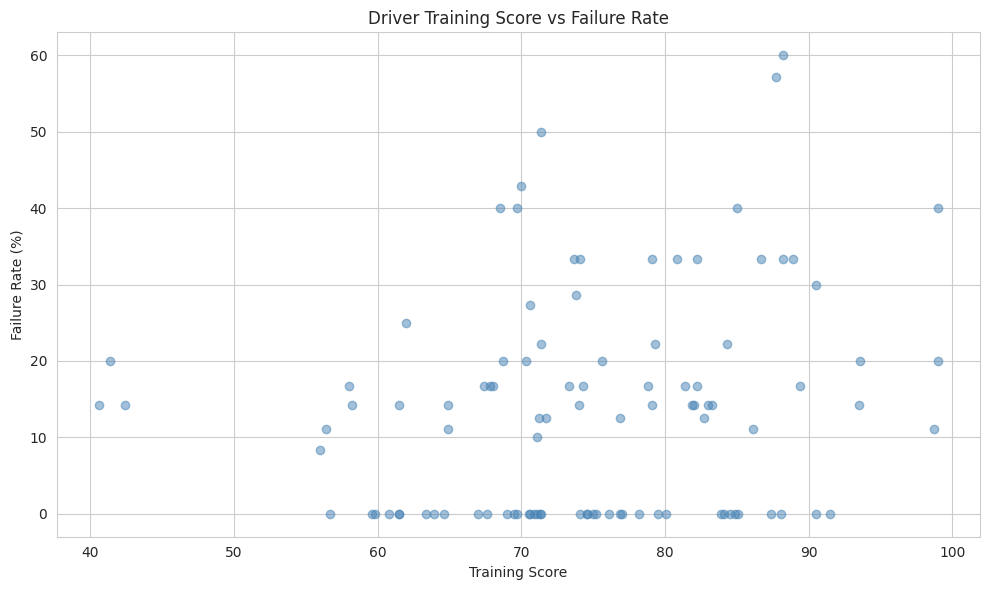

In [54]:
driver_plot = driver_dash[driver_dash["total_deliveries"] >= 5].copy()

plt.figure(figsize=(10, 6))
plt.scatter(driver_plot["training_score"], driver_plot["fail_rate_pct"], alpha=0.5, color="steelblue")
plt.title("Driver Training Score vs Failure Rate")
plt.xlabel("Training Score")
plt.ylabel("Failure Rate (%)")
plt.tight_layout()
plt.show()

This scatter plot compares each driver’s training score with their delivery failure rate. Each dot is one driver.

There is no very clear pattern showing that higher training scores always lead to lower failure rates. Some drivers with high training scores still have high failure rates, while many drivers have a failure rate of 0%.

This suggests that delivery failures may not be caused by training alone. Other factors, such as route difficulty, hub or vehicle issues can also affect.

However drivers with high failure rates should still be reviewed, especially if they also have lower training scores or high route override counts.